# Lab 2: Data Preprocessing and Visualization

**Aim:** Data Preprocessing and Visualization

This lab focuses on performing data cleaning, preprocessing, and visualization to prepare datasets for machine learning tasks. Students will explore real-world datasets to identify and handle missing values, remove inconsistencies, and transform data into a suitable format for analysis. The lab also covers basic preprocessing techniques such as encoding categorical variables and scaling numerical features. In addition, students will use data visualization methods to examine data distributions, detect outliers, and understand relationships between features. These steps help ensure data quality and provide meaningful insights, forming a strong foundation for building accurate and reliable machine learning models.

### Prerequisite: Generate a sample dataset
We'll create a CSV file named `lab2_dataset.csv` with some missing values, dates, and inconsistent data for our experiments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create synthetic dataset
np.random.seed(42)
dates = pd.date_range('2023-01-01', periods=100)
data = {
    'Date': dates,
    'Age': np.random.randint(18, 65, 100).astype(float),
    'Salary': np.random.randint(30000, 120000, 100).astype(float),
    'Department': np.random.choice(['HR', 'IT', 'Finance', 'Marketing', 'it', 'H.R.'], 100),
    'Experience_Years': np.random.randint(1, 20, 100).astype(str) # string type for conversion later
}
df_mock = pd.DataFrame(data)

# Introduce missing values
df_mock.loc[5:15, 'Age'] = np.nan
df_mock.loc[20:25, 'Salary'] = np.nan
df_mock.loc[40:45, 'Department'] = np.nan

# Introduce outliers
df_mock.loc[90, 'Salary'] = 500000
df_mock.loc[91, 'Age'] = 120

df_mock.to_csv('lab2_dataset.csv', index=False)
print("lab2_dataset.csv created successfully!")
df_mock.head()

lab2_dataset.csv created successfully!


,Date,Age,Salary,Department,Experience_Years
0,2023-01-01,56.0,32695.0,it,17
1,2023-01-02,46.0,78190.0,HR,1
2,2023-01-03,32.0,35258.0,HR,16
3,2023-01-04,60.0,117538.0,Finance,12
4,2023-01-05,25.0,69504.0,H.R.,19


### Experiment 1
**Objective:** Write a Python program to Load a dataset using Pandas. Identify missing values using `isnull()` and `notnull()`. Display the total count of missing values in each column.

In [2]:
# Load dataset
df = pd.read_csv('lab2_dataset.csv')

# Identify missing values
print("Using isnull():\n", df.isnull().head())
print("\nUsing notnull():\n", df.notnull().head())

# Display total count of missing values
print("\nTotal count of missing values in each column:")
print(df.isnull().sum())

Using isnull():
     Date    Age  Salary  Department  Experience_Years
0  False  False   False       False             False
1  False  False   False       False             False
2  False  False   False       False             False
3  False  False   False       False             False
4  False  False   False       False             False

Using notnull():
    Date   Age  Salary  Department  Experience_Years
0  True  True    True        True              True
1  True  True    True        True              True
2  True  True    True        True              True
3  True  True    True        True              True
4  True  True    True        True              True

Total count of missing values in each column:
Date                 0
Age                 11
Salary               6
Department           6
Experience_Years     0
dtype: int64


### Experiment 2
**Objective:** Write a program to Read a CSV dataset. Remove rows containing missing values. Compare the dataset size before and after cleaning.

In [3]:
# Read dataset
df_exp2 = pd.read_csv('lab2_dataset.csv')

# Size before cleaning
size_before = df_exp2.shape
print(f"Dataset size before cleaning: {size_before}")

# Remove rows with missing values
df_cleaned = df_exp2.dropna()

# Size after cleaning
size_after = df_cleaned.shape
print(f"Dataset size after cleaning: {size_after}")

Dataset size before cleaning: (100, 5)
Dataset size after cleaning: (77, 5)


### Experiment 3
**Objective:** Write a Python program to load a dataset with missing values. Replace missing numerical values using `fillna()` with mean or median. Replace missing categorical values using appropriate constants.

In [4]:
df_exp3 = pd.read_csv('lab2_dataset.csv')

# Replace missing numerical values
mean_age = df_exp3['Age'].mean()
median_salary = df_exp3['Salary'].median()

df_exp3['Age'].fillna(mean_age, inplace=True)
# pandas 2.1.0+ prefers avoiding inplace, so we can also do:
df_exp3['Salary'] = df_exp3['Salary'].fillna(median_salary)

# Replace missing categorical values
df_exp3['Department'] = df_exp3['Department'].fillna('Unknown')

print("Missing values after replacement:")
print(df_exp3.isnull().sum())

Missing values after replacement:
Date                0
Age                 0
Salary              0
Department          0
Experience_Years    0
dtype: int64


C:\Users\ishan\AppData\Local\Temp\ipykernel_27476\2829751503.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_exp3['Age'].fillna(mean_age, inplace=True)


### Experiment 4
**Objective:** Write a program to load a dataset, Display column data types, Convert selected columns to appropriate data types using `astype()`. Verify the changes.

In [5]:
df_exp4 = pd.read_csv('lab2_dataset.csv')

print("Data types before conversion:")
print(df_exp4.dtypes)

# Convert Experience_Years to float (it was loaded as float or object depending on Pandas version, let's ensure it's loaded as object/string and converted to int)
# Wait, it was saved as string. pd.read_csv might infer it as int or float. Let's make sure it's read as string first.
df_exp4['Experience_Years'] = df_exp4['Experience_Years'].astype(str)

print("\nConverting Experience_Years to float...")
df_exp4['Experience_Years'] = df_exp4['Experience_Years'].astype(float)

# Convert Age to float32
df_exp4['Age'] = df_exp4['Age'].astype('float32')

print("\nData types after conversion:")
print(df_exp4.dtypes)

Data types before conversion:
Date                 object
Age                 float64
Salary              float64
Department           object
Experience_Years      int64
dtype: object

Converting Experience_Years to float...

Data types after conversion:
Date                 object
Age                 float32
Salary              float64
Department           object
Experience_Years    float64
dtype: object


### Experiment 5
**Objective:** Write a Python program to load a dataset, rename column names using `rename()` for better readability. Display the updated DataFrame.

In [6]:
df_exp5 = pd.read_csv('lab2_dataset.csv')

# Rename columns
df_exp5 = df_exp5.rename(columns={
    'Experience_Years': 'Years_of_Experience',
    'Department': 'Dept'
})

print("Updated DataFrame Columns:")
print(df_exp5.columns.tolist())
df_exp5.head()

Updated DataFrame Columns:
['Date', 'Age', 'Salary', 'Dept', 'Years_of_Experience']


,Date,Age,Salary,Dept,Years_of_Experience
0,2023-01-01,56.0,32695.0,it,17
1,2023-01-02,46.0,78190.0,HR,1
2,2023-01-03,32.0,35258.0,HR,16
3,2023-01-04,60.0,117538.0,Finance,12
4,2023-01-05,25.0,69504.0,H.R.,19


### Experiment 6
**Objective:** Write a program to identify inconsistent or incorrect values in a dataset. Replace them using the `replace()` function. Verify the corrected data.

In [7]:
df_exp6 = pd.read_csv('lab2_dataset.csv')

print("Unique Departments before correction:")
print(df_exp6['Department'].unique())

# Replace inconsistent values
df_exp6['Department'] = df_exp6['Department'].replace({'it': 'IT', 'H.R.': 'HR'})

print("\nUnique Departments after correction:")
print(df_exp6['Department'].unique())

Unique Departments before correction:
['it' 'HR' 'Finance' 'H.R.' 'IT' 'Marketing' nan]

Unique Departments after correction:
['IT' 'HR' 'Finance' 'Marketing' nan]


### Experiment 7
**Objective:** Write a Python program to load a dataset. Create a line plot to show trends over time. Create a bar plot to compare categorical data.

C:\Users\ishan\AppData\Local\Temp\ipykernel_27476\831705859.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  axes[0].plot(df_exp7_sorted['Date'], df_exp7_sorted['Salary'].fillna(method='ffill'), marker='o', markersize=4, linestyle='-', color='m')


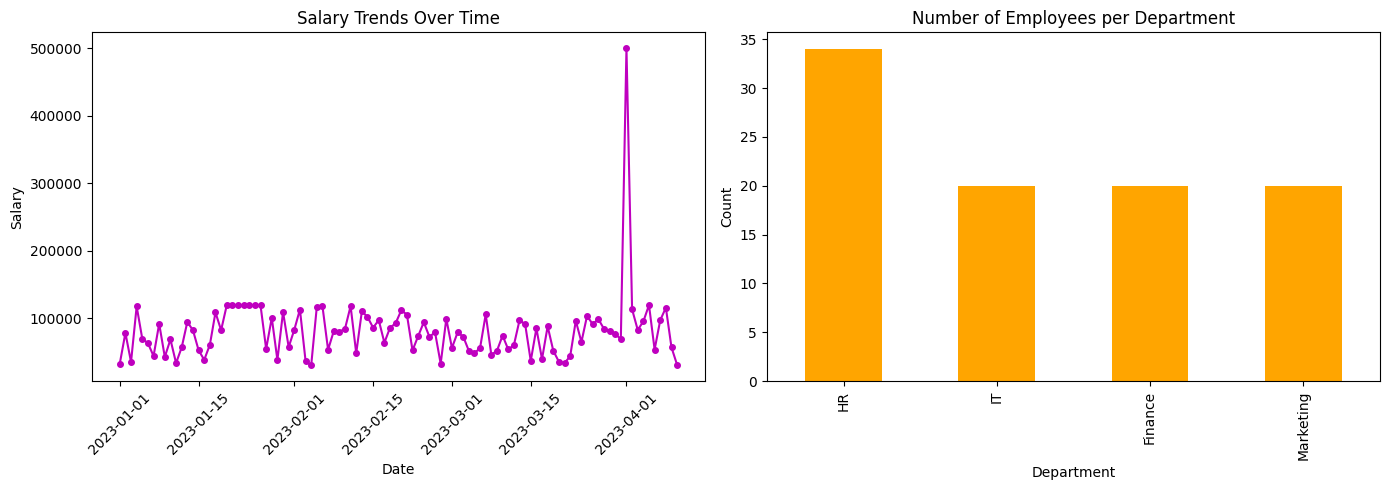

In [8]:
df_exp7 = pd.read_csv('lab2_dataset.csv')
df_exp7['Date'] = pd.to_datetime(df_exp7['Date'])

# Setup the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot: Salary trend over time
# Fill NA for plotting smoothly
df_exp7_sorted = df_exp7.sort_values('Date')
axes[0].plot(df_exp7_sorted['Date'], df_exp7_sorted['Salary'].fillna(method='ffill'), marker='o', markersize=4, linestyle='-', color='m')
axes[0].set_title('Salary Trends Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Salary')
axes[0].tick_params(axis='x', rotation=45)

# Bar plot: Compare categorical data (Department counts)
dept_counts = df_exp7['Department'].replace({'it': 'IT', 'H.R.': 'HR'}).value_counts()
dept_counts.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Number of Employees per Department')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Experiment 8
**Objective:** Write a program to load a dataset. Create a scatter plot between two numerical features. Interpret the relationship between the features.

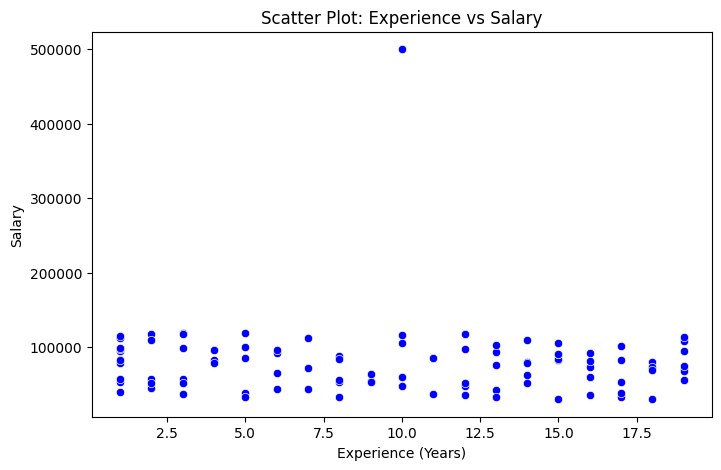

Interpretation: Depending on the synthetic data generation, you might see a random spread or a positive correlation between Experience and Salary.


In [9]:
df_exp8 = pd.read_csv('lab2_dataset.csv')

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_exp8, x='Years_of_Experience' if 'Years_of_Experience' in df_exp8.columns else 'Experience_Years', y='Salary', color='blue')
plt.title('Scatter Plot: Experience vs Salary')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary')
plt.show()

print("Interpretation: Depending on the synthetic data generation, you might see a random spread or a positive correlation between Experience and Salary.")

### Experiment 9
**Objective:** Write a Python program to load a dataset. Plot a histogram for a selected numerical feature. Analyse data distribution and skewness.

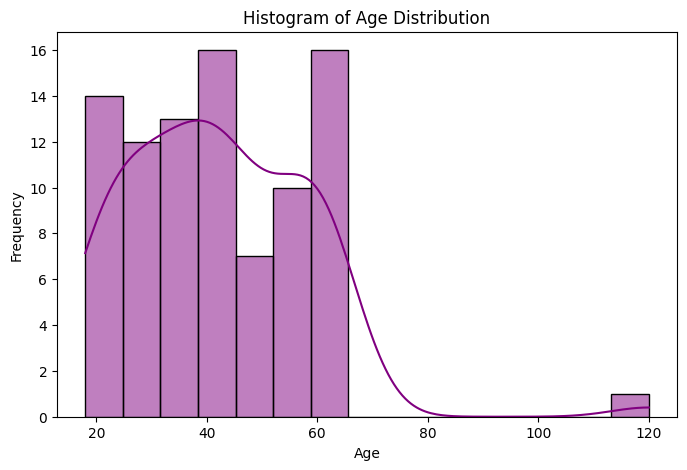

Skewness of Age: 1.136
The distribution is positively (right) skewed.


In [10]:
df_exp9 = pd.read_csv('lab2_dataset.csv')

plt.figure(figsize=(8, 5))
sns.histplot(df_exp9['Age'].dropna(), bins=15, kde=True, color='purple')
plt.title('Histogram of Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

skewness = df_exp9['Age'].skew()
print(f"Skewness of Age: {skewness:.3f}")
if skewness > 0.5:
    print("The distribution is positively (right) skewed.")
elif skewness < -0.5:
    print("The distribution is negatively (left) skewed.")
else:
    print("The distribution is relatively symmetrical.")

### Experiment 10
**Objective:** Write a program to load a dataset. Create a boxplot for numerical attributes. Identify and interpret potential outliers.

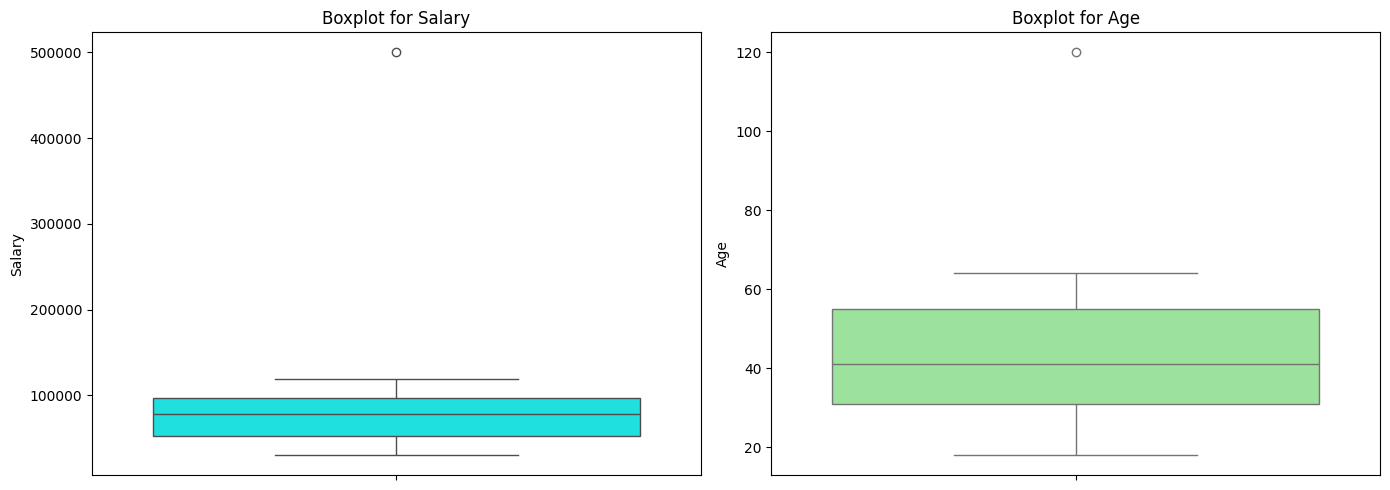

Interpretation:
- Points outside the whiskers on the boxplots represent potential outliers.
- In our synthetic dataset, we intentionally added extreme values (e.g., age 120 and salary 500,000) which should appear as outliers as individual points above/below the main box plotting area.


In [11]:
df_exp10 = pd.read_csv('lab2_dataset.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot for Salary
sns.boxplot(y=df_exp10['Salary'], ax=axes[0], color='cyan')
axes[0].set_title('Boxplot for Salary')

# Boxplot for Age
sns.boxplot(y=df_exp10['Age'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot for Age')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Points outside the whiskers on the boxplots represent potential outliers.")
print("- In our synthetic dataset, we intentionally added extreme values (e.g., age 120 and salary 500,000) which should appear as outliers as individual points above/below the main box plotting area.")